
# CADERNO DE EXERCICIOS - Analise de Dados com Pandas e Seaborn
 Base de dados: modafina_vendas.csv (loja ficticia de roupas)
# Como usar:
   - Coloque o arquivo modafina_vendas.csv na pasta data.
  - Leia a instrucao de cada celula e escreva seu codigo logo abaixo dela.


In [1]:
# Exercicio 1
# Importe as bibliotecas pandas e seaborn e configure o tema visual dos graficos.

import pandas as pd
import seaborn as sns

# Configura o tema visual do seaborn
sns.set_theme(style="whitegrid")

In [2]:
# Exercicio 2
# Carregue o arquivo modafina_vendas.csv em um DataFrame
# e mostre as primeiras linhas para conhecer os dados.

import pandas as pd

# Carregar o ficheiro CSV para um DataFrame
df = pd.read_csv('dataset_aula02_exercicio_modafina.csv')

# Exibir as primeiras 5 linhas para conhecer os dados
display(df.head())

,data_venda,categoria_produto,tamanho,preco,quantidade,estado,forma_pagamento,nota_avaliacao
0,2024-01-01,Calças,G,177.95,1,SP,Boleto,4.1
1,2024-01-01,Camisetas,G,52.12,1,SP,Cartão,4.3
2,2024-01-03,Calças,G,213.45,3,PR,Pix,3.9
3,2024-01-03,Camisetas,M,76.81,1,RJ,Pix,4.9
4,2024-01-03,Acessórios,M,132.39,2,RS,Pix,2.9


In [3]:
# Exercicio 3
# Mostre quantas linhas e quantas colunas a base de dados possui.
# Mostra o formato do DataFrame (linhas, colunas)
print(df.shape)
print(df.tail)

(700, 8)
<bound method NDFrame.tail of      data_venda categoria_produto tamanho   preco  quantidade estado  \
0    2024-01-01            Calças       G  177.95           1     SP   
1    2024-01-01         Camisetas       G   52.12           1     SP   
2    2024-01-03            Calças       G  213.45           3     PR   
3    2024-01-03         Camisetas       M   76.81           1     RJ   
4    2024-01-03        Acessórios       M  132.39           2     RS   
..          ...               ...     ...     ...         ...    ...   
695  2024-12-27          Calçados      GG  187.47           3     PR   
696  2024-12-27          Vestidos       M  230.97           1     CE   
697  2024-12-28          Calçados       P  141.28           3     SP   
698  2024-12-28          Calçados       M  245.78           3     BA   
699  2024-12-28         Camisetas       P   93.32           1     SP   

    forma_pagamento  nota_avaliacao  
0            Boleto             4.1  
1            Cartão 

In [4]:
# Exercicio 4
# Mostre as informacoes gerais da base: o nome das colunas,
# o tipo de cada uma e a quantidade de valores nao nulos.
print (df.info)

<bound method DataFrame.info of      data_venda categoria_produto tamanho   preco  quantidade estado  \
0    2024-01-01            Calças       G  177.95           1     SP   
1    2024-01-01         Camisetas       G   52.12           1     SP   
2    2024-01-03            Calças       G  213.45           3     PR   
3    2024-01-03         Camisetas       M   76.81           1     RJ   
4    2024-01-03        Acessórios       M  132.39           2     RS   
..          ...               ...     ...     ...         ...    ...   
695  2024-12-27          Calçados      GG  187.47           3     PR   
696  2024-12-27          Vestidos       M  230.97           1     CE   
697  2024-12-28          Calçados       P  141.28           3     SP   
698  2024-12-28          Calçados       M  245.78           3     BA   
699  2024-12-28         Camisetas       P   93.32           1     SP   

    forma_pagamento  nota_avaliacao  
0            Boleto             4.1  
1            Cartão        

In [5]:
# Exercicio 5
# Crie uma nova coluna chamada faturamento, multiplicando o preco
# pela quantidade de cada venda. Depois, mostre as primeiras linhas.
# Cria a coluna 'faturamento' multiplicando o preço pela quantidade
df['faturamento'] = df['preco'] * df['quantidade']

# Mostra as primeiras 5 linhas para conferir a nova coluna
display(df.head())

,data_venda,categoria_produto,tamanho,preco,quantidade,estado,forma_pagamento,nota_avaliacao,faturamento
0,2024-01-01,Calças,G,177.95,1,SP,Boleto,4.1,177.95
1,2024-01-01,Camisetas,G,52.12,1,SP,Cartão,4.3,52.12
2,2024-01-03,Calças,G,213.45,3,PR,Pix,3.9,640.35
3,2024-01-03,Camisetas,M,76.81,1,RJ,Pix,4.9,76.81
4,2024-01-03,Acessórios,M,132.39,2,RS,Pix,2.9,264.78


In [6]:
print(df['faturamento'].sum())

232687.91999999998


In [7]:
# Exercicio 6
# Calcule o faturamento total da loja (a soma da coluna faturamento).
# Em seguida, exiba esse valor formatado como moeda brasileira,
# no formato R$ 0.000,00 (exemplo: R$ 232.687,92).
# Calcula o faturamento total
faturamento_total = df['faturamento'].sum()

# Exibe o valor formatado
print(f"Faturamento total: R$ {faturamento_total:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

Faturamento total: R$ 232.687,92


In [8]:
# Exercicio 7
# Descubra quantos pedidos existem de cada categoria de produto.

# Conta a frequência de cada categoria de forma descendente
contagem_categorias = df['categoria_produto'].value_counts(ascending=False)

# Exibe o resultado
print(contagem_categorias)

categoria_produto
Camisetas     191
Calças        153
Vestidos      137
Calçados      118
Acessórios    101
Name: count, dtype: int64


In [ ]:
# Exercicio 8
# Descubra quanto cada categoria de produto faturou no total,
# ordenando da que mais faturou para a que menos faturou.
# Agrupa por categoria e soma o faturamento, depois ordena de forma decrescente
# 1. Agrupar, somar e ordenar (já tínhamos feito isto e estava correto)
faturamento_por_categoria = df.groupby('categoria_produto')['faturamento'].sum().sort_values(ascending=False)

# 2. Formatar o resultado para visualização (usando um DataFrame para ficar organizado)
df_resultado = faturamento_por_categoria.to_frame(name='Faturamento Total')

# 3. Aplicar a formatação de moeda brasileira (R$ 0.000,00)
# Criamos uma função lambda para substituir os separadores
pd.options.display.float_format = 'R${:,.2f}'.format 

# Exibir o DataFrame resultante
display(df_resultado)

,Faturamento Total
categoria_produto,
Calçados,"R$tomano67,848.29"
Vestidos,"R$tomano63,743.92"
Calças,"R$tomano51,954.17"
Camisetas,"R$tomano31,637.03"
Acessórios,"R$tomano17,504.51"


C:\Users\FIC\AppData\Local\Temp\ipykernel_25672\2333145025.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='categoria_produto',


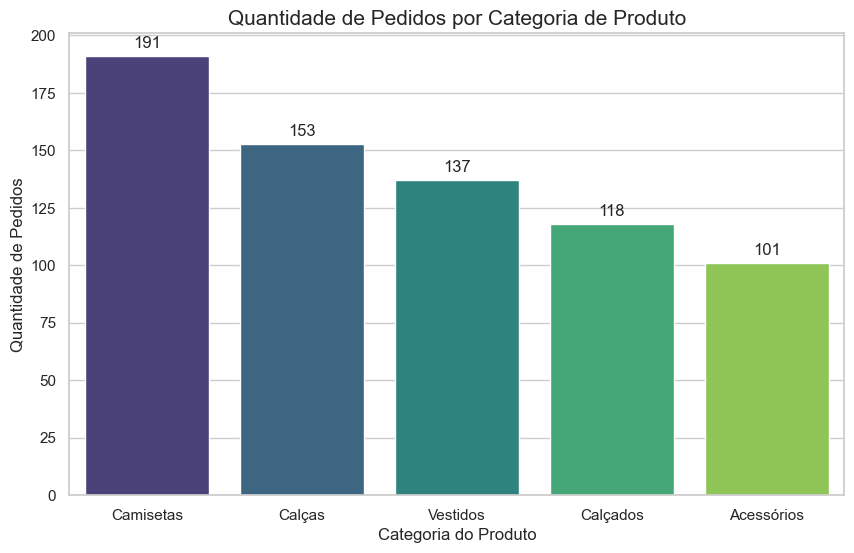

In [28]:
# Exercicio 9
# Crie um grafico que mostre a quantidade de pedidos por categoria de produto.
# Coloque um titulo no grafico e nomes nos eixos.

import matplotlib.pyplot as plt

# 1. Definir o tamanho do gráfico
plt.figure(figsize=(10, 6))

# 2. Criar o gráfico
# Armazenamos o gráfico na variável 'ax'
ax = sns.countplot(data=df, x='categoria_produto', 
                   order=df['categoria_produto'].value_counts().index, 
                   palette='viridis')

# 3. Adicionar os números em cima de cada barra de forma explícita
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

# 4. Títulos e eixos
plt.title('Quantidade de Pedidos por Categoria de Produto', fontsize=15);
plt.xlabel('Categoria do Produto', fontsize=12);
plt.ylabel('Quantidade de Pedidos', fontsize=12);

# Ajuste extra para garantir que os números não sejam cortados no topo
plt.ylim(0, df['categoria_produto'].value_counts().max() + 10)

plt.show();

C:\Users\FIC\AppData\Local\Temp\ipykernel_25672\3147594783.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria_produto', y='preco', palette='viridis')


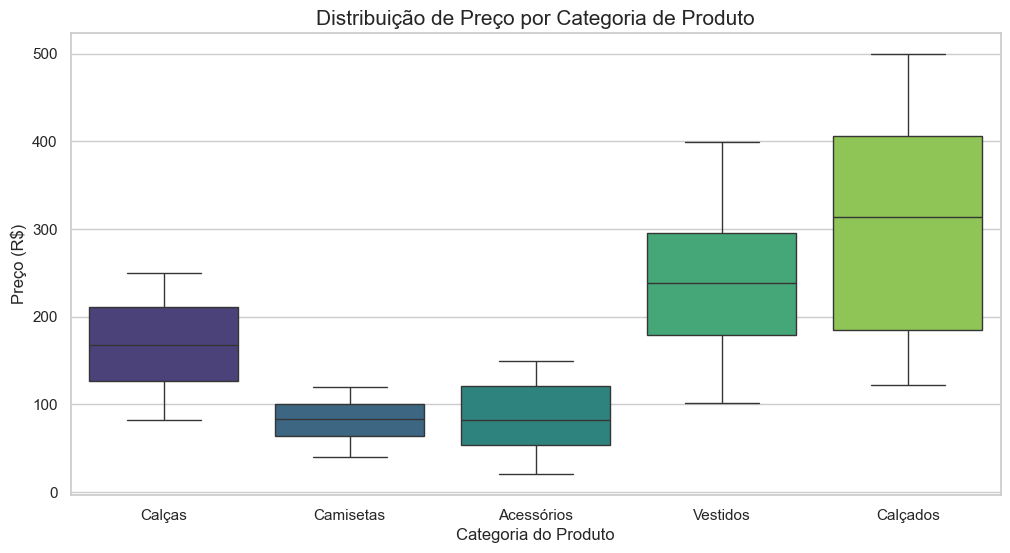

In [ ]:
# Exercicio 10
# Crie um grafico que compare a distribuicao do preco entre as
# diferentes categorias de produto. Coloque um titulo no grafico.

import matplotlib.pyplot as plt

# Define o tamanho da figura para ficar bem legível
plt.figure(figsize=(12, 6))

# Cria o boxplot
sns.boxplot(data=df, x='categoria_produto', y='preco', palette='viridis')

# Adiciona o título e nomes aos eixos
plt.title('Distribuição de Preço por Categoria de Produto', fontsize=15)
plt.xlabel('Categoria do Produto', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)

# Exibe o gráfico
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'yla'

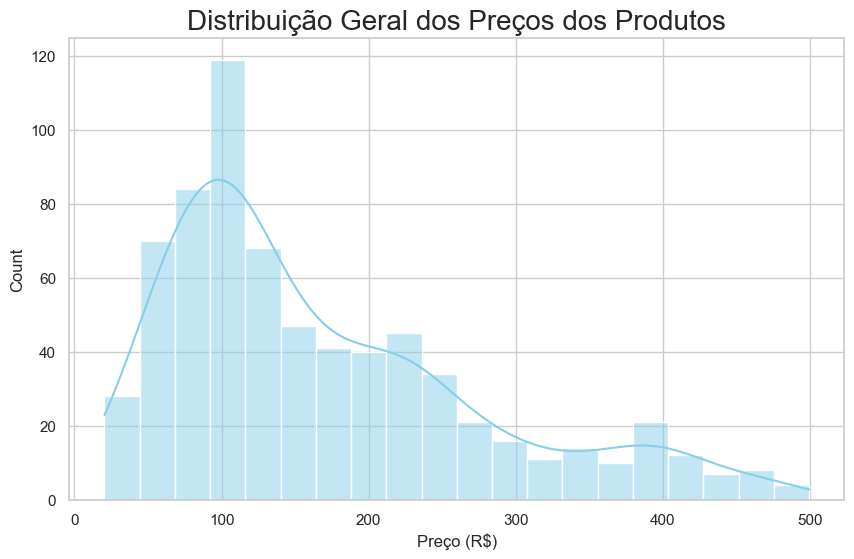

In [45]:
# Exercicio 11
# Crie um grafico que mostre a distribuicao dos precos dos produtos.
# Coloque um titulo no grafico.
import matplotlib.pyplot as plt

# Define o tamanho da figura
plt.figure(figsize=(10, 6))

# Cria o histograma com uma curva de densidade (kde=True)
sns.histplot(data=df, x='preco', bins=20, kde=True, color='skyblue')

# Adiciona título e nomes aos eixos
plt.title('Distribuição Geral dos Preços dos Produtos', fontsize=20)
plt.xlabel('Preço (R$)', fontsize=12)
plt.yla